In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import plotly.graph_objects as go
from scipy.integrate import trapezoid

import sys
sys.path.append("../")
from src.preprocessing import weigh_norm_densities, align_densities, df_to_densities, fit_kde_model
from src.transformations import ( 
                            mLQDT,
                            obtain_densities_from_lqd,
                            dens2lqd,
                            lqd2dens
                            )
                            

# Normal

In [105]:
mu = 0
sigma = 2
n = 256
normal_sample = np.random.normal(loc=mu, scale=sigma, size=n)
grid = np.linspace(normal_sample.min(), normal_sample.max(), n)

params = {'kernel': 'gaussian', 'bandwidth': 'scott'}
kde, density = fit_kde_model(normal_sample, params)

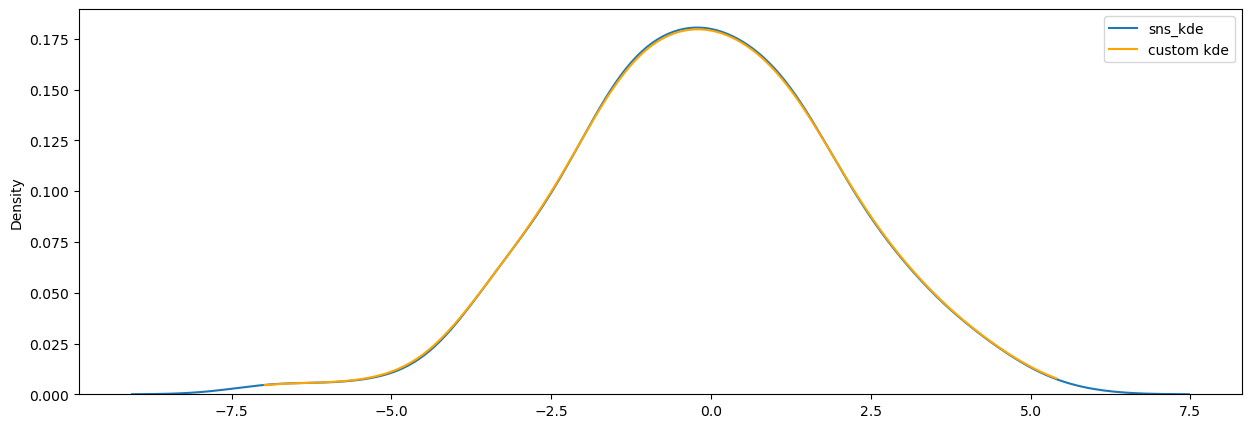

In [83]:
plt.figure(figsize=(15,5))

# sns.histplot(normal_sample, kde=True)
sns.kdeplot(normal_sample, label="sns_kde")
sns.lineplot(x=kde.grid, y=density, color="orange", label="custom kde")

plt.show()

In [91]:
lqd_grid = np.linspace(0,1,n)
t0_ = kde.grid[np.argmin(np.abs(kde.grid))]
lqdSup, lqd, c = dens2lqd(
                        dens = density,
                        dSup = grid,
                        lqdSup = lqd_grid,
                        t0=t0_
                )

Density does not integrate to 1 with tolerance 1e-5 - renormalizing now.


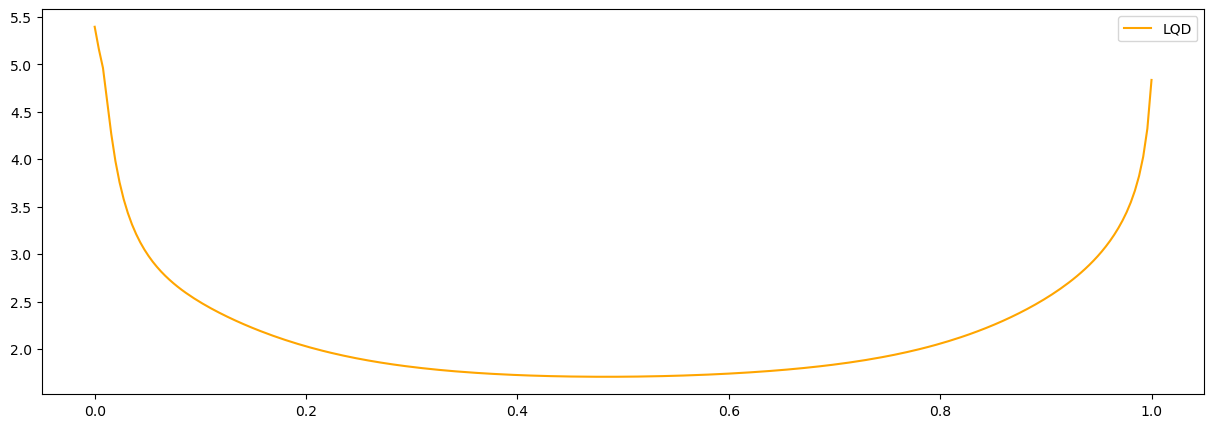

In [92]:
plt.figure(figsize=(15,5))

sns.lineplot(x=lqdSup, y=lqd, color="orange", label="LQD")

plt.show()

In [93]:
dSup, dens = lqd2dens(lqd, lqdSup, c=c, dSup=kde.grid)

c not in lqdSup — resetting to closest value.


/Users/vizzotto/Documents/GitHub/densities4risk/notebooks/../src/transformations.py:425: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  shift_v, _ = quad(fexp, lqdSup[0], lqdSup[c_ind])


In [99]:
fig = go.Figure()

# Gaussian KDE
fig.add_trace(
    go.Scatter(
        x=kde.grid,
        y=density,
        mode="lines",
        name="custom kde",
        line=dict(color="black")
    )
)

# Gaussian KDE
fig.add_trace(
    go.Scatter(
        x=dSup,
        y=dens,
        mode="lines",
        name="backwards custom kde",
        line=dict(color="red")
    )
)


fig.show()

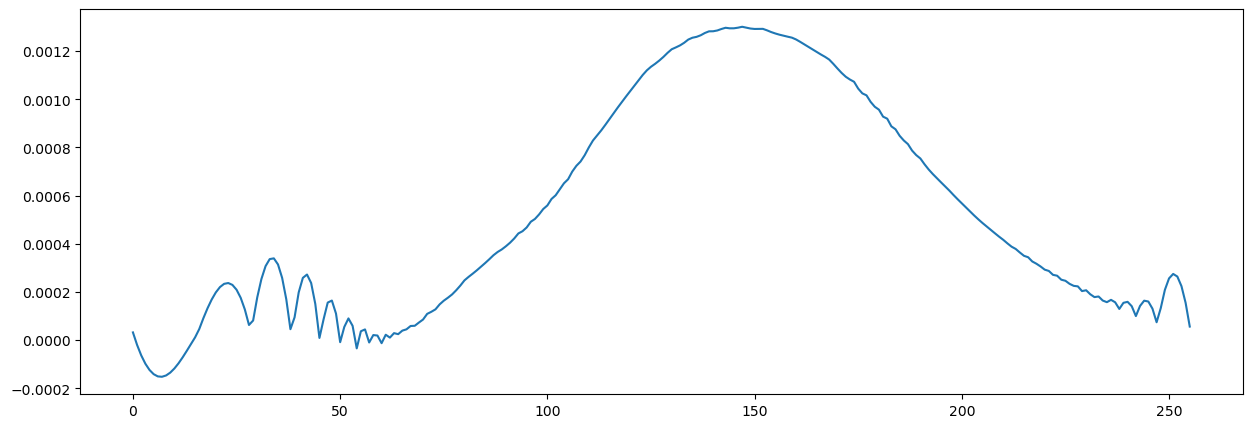

In [97]:
plt.figure(figsize=(15,5))

plt.plot(dens - density)

plt.show()

# Empiral density

In [2]:
# Dados
data_path = "../data/processed/"
returns_path = ''.join([data_path, 'ibovespa_treated.xlsx'])
df = pd.read_excel(returns_path, index_col="time")
df.head()

,2024-12-02,2024-12-03,2024-12-04,2024-12-05,2024-12-06,2024-12-09,2024-12-10,2024-12-11,2024-12-12,2024-12-13,...,2025-11-14,2025-11-17,2025-11-18,2025-11-19,2025-11-21,2025-11-24,2025-11-25,2025-11-26,2025-11-27,2025-11-28
time,,,,,,,,,,,,,,,,,,,,,
10:00:00,0.000011,-0.000372,-0.000035,0.007233,-0.001305,-0.000459,0.002388,0.002212,-0.008001,-0.000824,...,-0.000957,-0.002307,-0.003734,-0.005020,-0.001139,-0.000255,0.002339,0.004176,-0.000224,-0.000238
10:05:00,-0.002271,0.003372,0.001716,0.005538,0.000069,0.006429,0.002343,0.001918,-0.007582,-0.000413,...,-0.001522,0.000739,-0.000613,0.000306,-0.002021,-0.000810,0.001557,-0.001565,-0.000193,0.002906
10:10:00,-0.000582,0.002832,-0.000502,0.000739,0.000261,0.001891,0.000775,-0.001172,0.000216,-0.000432,...,0.000360,-0.000105,-0.000159,-0.000362,0.000092,0.001131,0.001170,0.000202,0.000556,0.000475
10:15:00,-0.001997,0.001091,0.000111,-0.000192,0.000407,-0.001392,-0.000477,-0.001526,0.000198,-0.001821,...,0.001121,-0.000284,0.003272,-0.001107,-0.001012,-0.000174,0.001002,0.001815,-0.000168,0.000973
10:20:00,-0.000037,-0.000505,-0.000327,-0.000580,-0.000436,-0.000405,0.001263,0.000676,-0.002667,0.001033,...,0.000449,0.000335,0.000853,0.000981,-0.000057,-0.000096,0.000832,0.001951,0.001060,-0.001004


In [ ]:
i = 100
t = df.columns[i]
n = 256

Z_t = df.loc[:, t]
params = {'kernel': 't_student', 'bandwidth': 'scott'}
# params = {"kernel": "t_student", "bandwidth": "scott", "df": 2, "adaptive": True}

## Local grid

In [59]:
grid = np.linspace(Z_t.min(), Z_t.max().max(), n)

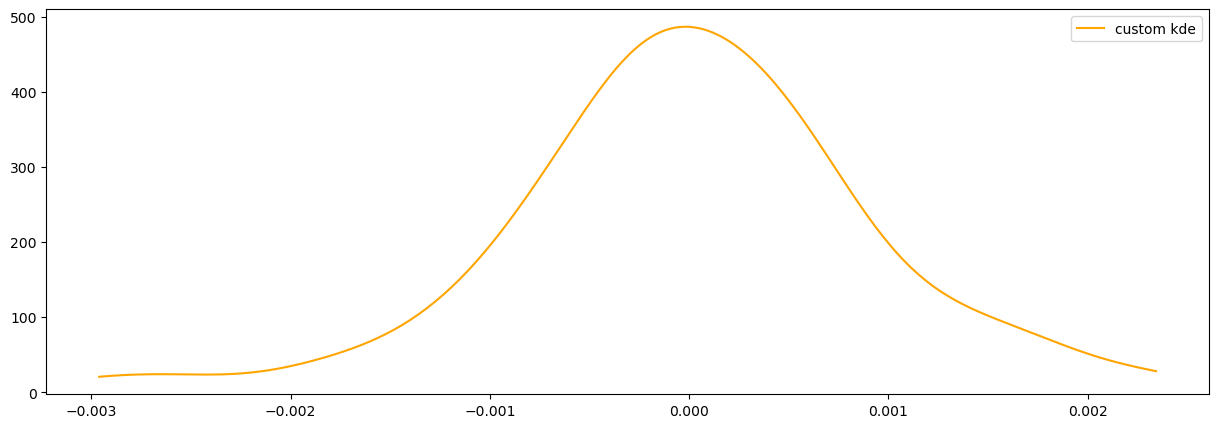

In [60]:
kde, density = fit_kde_model(Z_t, params)

plt.figure(figsize=(15,5))

sns.lineplot(x=grid, y=density, color="orange", label="custom kde")

plt.show()

Density does not integrate to 1 with tolerance 1e-5 - renormalizing now.


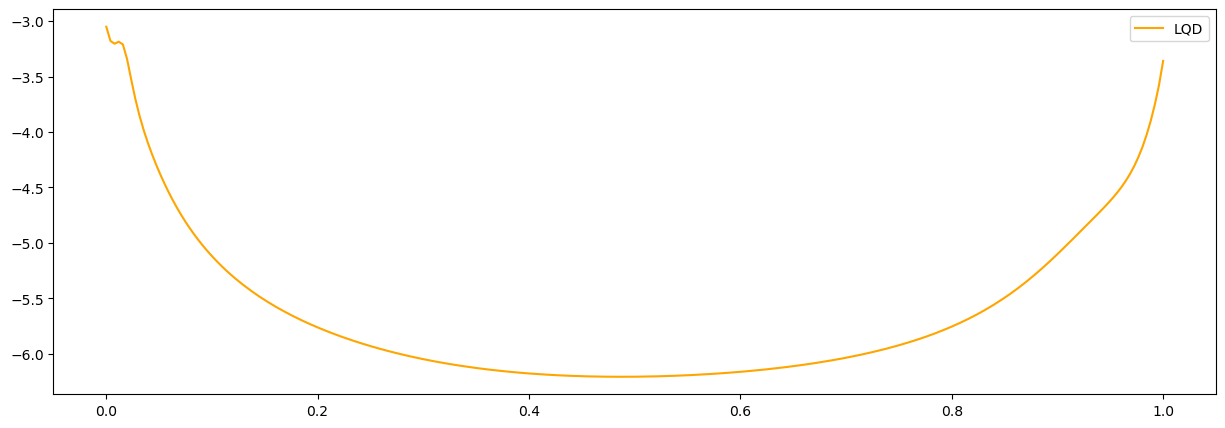

In [61]:
lqd_grid = np.linspace(0,1,n)
t0_ = grid[np.argmin(np.abs(kde.grid))]
lqdSup, lqd, c = dens2lqd(
                        dens = density,
                        dSup = grid,
                        lqdSup = lqd_grid,
                        t0=t0_
                )

# lqdSup, lqd = lqdSup[1:-1], lqd[1:-1]

plt.figure(figsize=(15,5))

sns.lineplot(x=lqdSup, y=lqd, color="orange", label="LQD")

plt.show()

In [62]:
dSup, dens = lqd2dens(lqd, lqdSup, c=c, dSup=kde.grid)

fig = go.Figure()

# Gaussian KDE
fig.add_trace(
    go.Scatter(
        x=kde.grid,
        y=density,
        mode="lines",
        name="custom kde",
        line=dict(color="black")
    )
)

# Gaussian KDE
fig.add_trace(
    go.Scatter(
        x=dSup,
        y=dens,
        mode="lines",
        name="backwards custom kde",
        line=dict(color="red")
    )
)


fig.show()

c not in lqdSup — resetting to closest value.


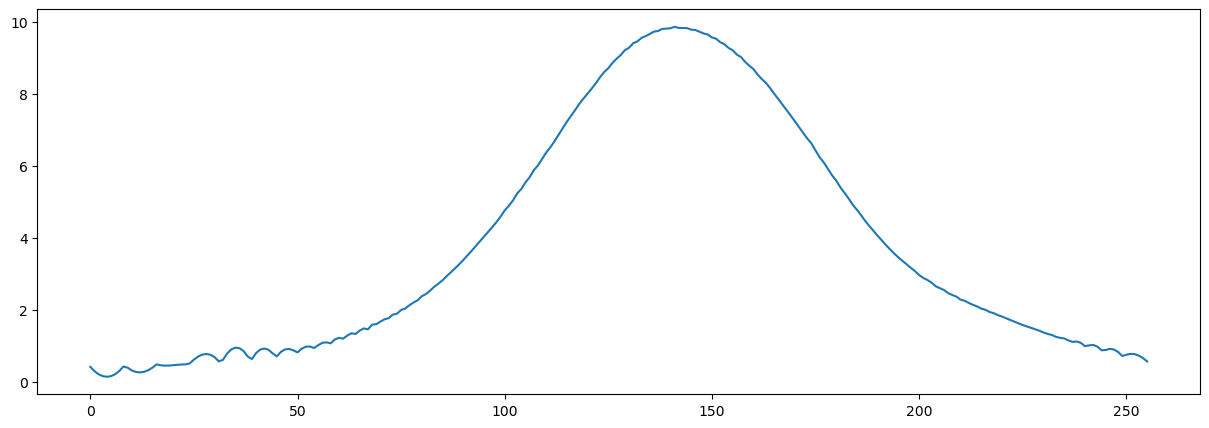

In [63]:
plt.figure(figsize=(15,5))

plt.plot(dens - density)

plt.show()

## Global grid

In [53]:
grid = np.linspace(df.min().min(), df.max().max(), n)

In [54]:
kde, density = fit_kde_model(Z_t, params, grid=grid)
# print(trapezoid(density/trapezoid(density, kde.grid), kde.grid))

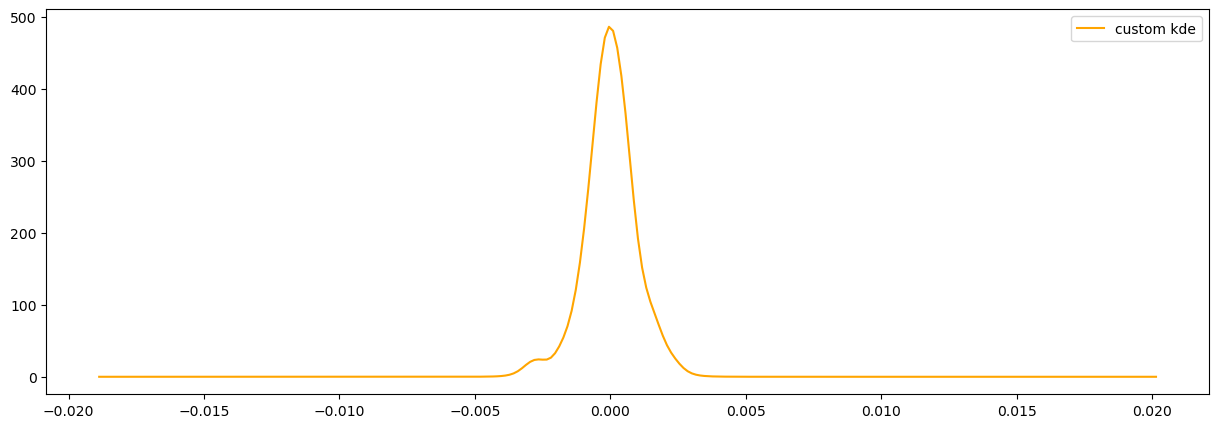

In [55]:
plt.figure(figsize=(15,5))

sns.lineplot(x=grid, y=density, color="orange", label="custom kde")

plt.show()

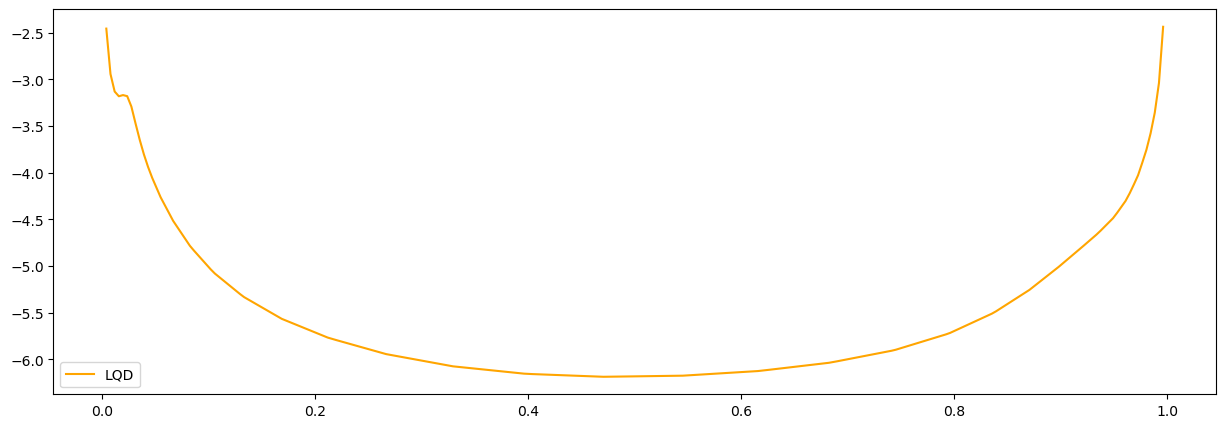

In [56]:
lqd_grid = np.linspace(0,1,n)
t0_ = grid[np.argmin(np.abs(grid))]
lqdSup, lqd, c = dens2lqd(
                        dens = density,
                        dSup = grid,
                        lqdSup = lqd_grid,
                        t0=t0_
                )

lqdSup, lqd = lqdSup[1:-1], lqd[1:-1]

plt.figure(figsize=(15,5))

sns.lineplot(x=lqdSup, y=lqd, color="orange", label="LQD")

plt.show()

In [57]:
dSup, dens = lqd2dens(lqd, lqdSup, c=c, dSup=grid)

fig = go.Figure()

# Gaussian KDE
fig.add_trace(
    go.Scatter(
        x=grid,
        y=density,
        mode="lines",
        name="custom kde",
        line=dict(color="black")
    )
)

# Gaussian KDE
fig.add_trace(
    go.Scatter(
        x=dSup,
        y=dens,
        mode="lines",
        name="backwards custom kde",
        line=dict(color="red")
    )
)


fig.show()

Problem with LQD domain boundaries — resetting to default.
c not in lqdSup — resetting to closest value.


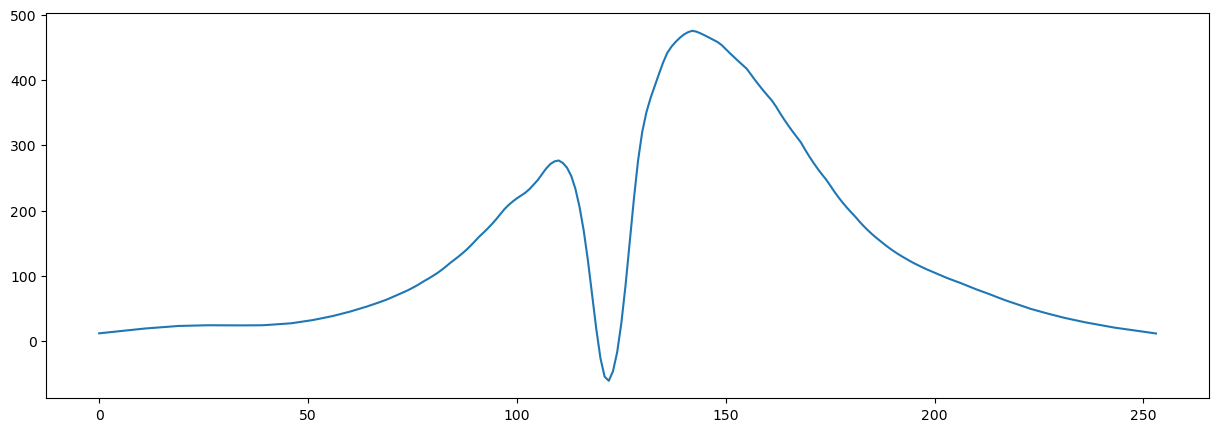

In [40]:
plt.figure(figsize=(15,5))

plt.plot(dens - density[1:-1])

plt.show()